# Textual description of the problem

For this problem, we will play the role of a boutique investment firm, **UC3M Hedge Fund**, known for its innovative strategies and the use of cuttind-edge tecgnology to decide in what to invest. Our clients want exposure to the **American market**, particularly the **S&P 500 Index**, which represents the performance of 500 of the largest publicly traded companies in the United States.

However, we face a challenge. Buying all 500 stocks in the index is not practical for a firm like ours due to:
1. **High Transaction Costs**: Purchasing and maintaining such a large number of positions incurs significant trading fees.
2. **Complexity**: Managing such a broad portfolio requires substantial resources and infrastructure.

Another option would be to invest in an **indexed mutual fund or ETF**. However:
- Many of these funds charge **management fees**, which, while small, can significantly impact long-term returns.

---

### Our Innovative Solution

To address these challenges, our firm proposes an innovative strategy:
1. **Replicate the Performance of the S&P 500**: Build a portfolio that closely mimics the returns of the index but using just a few stocks.
2. **Select Only a Few Stocks**: Use a **subset of stocks** from the S&P 500 that together replicate its behavior, balancing diversification and simplicity.
3. **Optimize Transaction Costs**: Ensure that the portfolio is cost-effective to rebalance by considering transaction fees in the optimization.

This approach ensures that our clients enjoy the benefits of index performance without the burden of owning all 500 stocks or paying high fund management fees.

---

### The Technical Challenge

Out team of investment analysts has already decided what are the stocks that we may buy, but now we face a complex optimization problem:
1. **Tracking the Index**:
   - How closely can a portfolio with a limited number of stocks mimic the performance of the S&P 500?
   - What weights should be assigned to each selected stock? Should we buy all the stocks that the investment analyst had suggested?

2. **Balancing Costs**:
   - How can we minimize the costs of buying and rebalancing the portfolio if needed?
   - How can transaction costs be incorporated into the decision-making process?

3. **Applying Constraints**:
   - Ensure the portfolio meets practical constraints, like not over-allocating to any single stock and staying within budget, have a low risk, etc.

---

### Our Optimization Model

To solve this, we use a **non-linear optimization model**:
- The **objective** is to minimize the **tracking error** (i.e., have a performance as similar to the SP500 as possible) while accounting for **transaction costs**.
- The **constraints** include maintaining total portfolio weight within a fixed budget, limiting allocations per stock...

# **Mathematical Formulation of the Problem**

#### **Objective**
As said, the goal is to **replicate the performance of a financial index** (e.g., S&P 500) using a subset of available stocks. The optimization problem minimizes the **tracking error** (difference between portfolio and index returns) while considering **transaction costs** (we nay need to rebalance the porfotlio during, for example, periods of high volatility).

---

#### **Decision Variables**
- $w_i$: Proportion of the portfolio allocated to stock *i*, where *i* ⋹ *{1, 2, ..., N}*.

---

### **Objective Function**

The objective is to minimize the sum of:

1. **Tracking Error**: Measures the deviation between portfolio returns and index returns.
2. **Transaction Costs**: Accounts for rebalancing the portfolio based on changes in weights.

$$
\text{Minimize: } \mathcal{L}(w) = \sum_{t=1}^T \left( R_t^{\text{portfolio}} - R_t^{\text{index}} \right)^2 + \lambda \cdot \sum_{i=1}^N c_i \sqrt{|w_i - w_i^{\text{prev}}|}
$$

**Where**:

- $R_t^{\text{portfolio}}$ = $\sum_{i=1}^N w_i \cdot R_{i,t}$: Portfolio return at time $t$.
- $R_t^{\text{index}}$: Index return at time $t$.
- $c_i$ : Transaction cost coefficient for stock $ i$.
- $w_i^{\text{prev}}$: Previous portfolio weight for stock $ $.
- $\lambda$: Regularization parameter controlling the trade-off between tracking error and transaction costs.



### **Detailed Explanation of the Objective Function**


#### **1. Tracking Error: $ \sum_{t=1}^T (R_t^{\text{portfolio}} - R_t^{\text{index}})^2 $**

**What It Does**:  
Tracking error measures the deviation between the portfolio’s returns and the index’s returns. The goal is to ensure the portfolio behaves as similarly as possible to the index over time.

**Why Are the Terms Squared?**  
- Squaring the difference emphasizes **larger deviations**, penalizing portfolios that significantly deviate from the index.
- Squaring also removes negative signs, ensuring all deviations contribute positively to the total error.
- This makes the tracking error a **convex function**, which simplifies optimization.

**Why It Matters**:  
- Minimizing tracking error ensures that the portfolio closely mimics the performance of the index.
- Without this term, the portfolio might diverge significantly from the index, failing its primary purpose.

---

#### **2. Transaction Costs: $ \lambda \cdot \sum_{i=1}^N c_i \sqrt{|w_i - w_i^{\text{prev}}|} $**

**What It Does**:  
The transaction cost term models the **real-world expenses of rebalancing** a portfolio. It penalizes large changes in portfolio weights compared to a previous allocation, reflecting costs like brokerage fees or market impact.

**Why Include Transaction Costs?**  
- Rebalancing a portfolio (buying or selling stocks to adjust weights) incurs expenses. Ignoring these costs would lead to an impractical strategy that frequently adjusts the portfolio without considering the financial impact.
- By penalizing large weight changes, the transaction cost term encourages **stability** in portfolio allocations, reducing the need for frequent trading.

**Why Use Absolute Values ($ |w_i - w_i^{\text{prev}}| $)?**
- Absolute values capture both **increases** and **decreases** in weights, as both require trading activity and thus incur costs.

**Why Take the Square Root ($ \sqrt{|w_i - w_i^{\text{prev}}|} $)?**
- The square root models **diminishing marginal costs**:
  - Small adjustments in weights result in proportionally smaller costs.
  - Larger changes incur proportionally higher costs but less steeply as changes grow, reflecting the nonlinear nature of trading expenses.

**What Does $ c_i $ Represent?**
- $ c_i $ is a coefficient that represents the **cost per unit of trading** for stock $ i $. It accounts for factors like:
  - Liquidity: Stocks with lower liquidity typically have higher trading costs.
  - Spreads: Larger bid-ask spreads increase transaction costs.
  - Brokerage fees: Some stocks might have higher fees due to market conditions.

**Role of $ \lambda $**:
- $ \lambda $ controls the balance between minimizing tracking error and transaction costs:
  - A **small $ \lambda $** prioritizes minimizing tracking error, possibly leading to frequent rebalancing and higher costs.
  - A **large $ \lambda $** emphasizes reducing transaction costs, potentially increasing tracking error.


#### **3. Results of Solving the Objective Function**
The results of solving the optimization problem include the **Optimal Portfolio Weights ($ w_i $)**:
   - These weights represent the proportion of the portfolio allocated to each stock.
   - For example, if $ w_i = 0.2 $, 20% of the portfolio is allocated to stock $ i $.

---

#### **Constraints**
1. **Budget Constraint**:
   The budget constraint ensures that the total allocation of the portfolio adds up to the available investment capital (normalized to 1). This prevents the optimizer from exceeding the budget or under-allocating the portfolio, guaranteeing that all the capital is efficiently deployed across the selected stocks.

   $$
   \sum_{i=1}^N w_i = 1
   $$

2. **Non-Negativity**:
   This constraint enforces that no stock is assigned a negative weight, meaning short selling is not allowed. It ensures that the portfolio consists only of long positions, reflecting a conservative and practical investment strategy.
   $$
   w_i \geq 0 \quad \forall i \in \{1, 2, \dots, N\}
   $$

3. **Maximum Holdings**:
   The maximum holdings constraint limits the proportion of the portfolio that can be allocated to any single stock. This prevents over-concentration in one asset, reducing the risk of significant losses from poor performance in a single stock.
   $$
   w_i \leq w_{\text{max}} \quad \forall i \in \{1, 2, \dots, N\}
   $$

4. **Risk Constraint**:
   The risk constraint ensures that the portfolio variance, a measure of its overall risk, does not exceed a specified threshold. This helps maintain a desired risk profile, ensuring that the portfolio aligns with the investor’s tolerance for volatility and uncertainty.
   $$
   \mathbf{w}^\top \mathbf{\Sigma} \mathbf{w} \leq \text{Risk Threshold}
   $$
   Where $ \mathbf{\Sigma} $ is the covariance matrix of stock returns.

5. **Diversification Constraint**:
   This constraint promotes diversification by requiring the portfolio to meet a minimum Shannon entropy threshold. Higher entropy indicates a more evenly distributed allocation, avoiding over-concentration in a few stocks and enhancing the portfolio’s resilience to market fluctuations.
   $$
   -\sum_{i=1}^N w_i \log(w_i) \geq \text{Entropy Threshold}
   $$



---

#### **Summary of the Problem**
$$
\begin{aligned}
\text{Minimize:} & \quad \sum_{t=1}^T \left( R_t^{\text{portfolio}} - R_t^{\text{index}} \right)^2 + \lambda \cdot \sum_{i=1}^N c_i \sqrt{|w_i - w_i^{\text{prev}}|} \\\\
\text{Subject to:} & \quad \sum_{i=1}^N w_i = 1 \quad \text{(Budget Constraint)} \\\\
                   & \quad w_i \geq 0 \quad \forall i \quad \text{(Non-Negativity)} \\\\
                   & \quad w_i \leq w_{\text{max}} \quad \forall i \quad \text{(Maximum Holdings)} \\\\
                   & \quad \mathbf{w}^\top \mathbf{\Sigma} \mathbf{w} \leq \text{Risk Threshold} \quad \text{(Risk Constraint)} \\\\
                   & \quad -\sum_{i=1}^N w_i \log(w_i) \geq \text{Entropy Threshold} \quad \text{(Diversification Constraint)}
\end{aligned}
$$

---

#### **Why Is the problem Non-Linear?**
1. **Transaction Costs**:
   The term $ \sqrt{|w_i - w_i^{\text{prev}}|} $ introduces non-linearity due to the square root and absolute value.
2. **Tracking Error**:
   The squared difference $ (R_t^{\text{portfolio}} - R_t^{\text{index}})^2 $ is quadratic in the portfolio weights.
3. **Risk Constraint**:
   The portfolio variance involves a quadratic term $ \mathbf{w}^\top \mathbf{\Sigma} \mathbf{w} $, which is inherently non-linear.
4. **Diversification Constraint**:
   The Shannon entropy term $ -\sum_{i=1}^N w_i \log(w_i) $ is non-linear because of the logarithmic operation.

## CODE

In [71]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import yfinance as yf
import matplotlib.pyplot as plt


First, we are going to load the historical data for both the selected stocks and the S&P 500 index using the `yfinance` library. The stocks are represented by their tickers, stored in the variable `symbols`, while the S&P 500 index is represented by `^GSPC`. This data includes adjusted closing prices for the period from January 1, 2020, to October 10, 2024.

Next, we extract the **closing prices** from the downloaded data for both the stocks and the index. If the S&P 500 index data is returned as a DataFrame, we will convert it to a Series and explicitly name it "S&P 500" to ensure consistency in processing.

Finally, we will compute the **daily returns** for both the stocks and the index using the `.pct_change()` method.

In [ ]:
# Define symbols and dates
symbols = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "META", "WMT", 
    "GS", "DUK", "LH", "TSLA", "JPM", "GE", "XOM", 
    "KO", "PG", "T"
]
index_symbol = "^GSPC"
start_date = "2020-01-01"
end_date   = "2024-10-10"

# Download data
stocks_data = yf.download(symbols, start=start_date, end=end_date)
index_data  = yf.download(index_symbol, start=start_date, end=end_date)

# Extract Close prices
stock_close_prices = stocks_data["Close"]
index_close_prices = index_data["Close"]

# Convert index_close_prices to Series if needed, and name it "S&P 500"
if isinstance(index_close_prices, pd.DataFrame):
    index_close_prices = index_close_prices.squeeze()
index_close_prices.name = "S&P 500"

# Calculate returns for reference
stock_returns = stock_close_prices.pct_change().dropna()
index_returns = index_close_prices.pct_change().dropna()


[*********************100%***********************]  16 of 16 completed
[*********************100%***********************]  1 of 1 completed


## Some understanding and visualization of the data

First, let's calculate the cumulative returns of each stock and the S&P 500 index, starting from a baseline value of 1.0 on the first available date
This will helo us see visually which stocks follow a similar pattern as the index.
The graph highlights that while most stocks follow a relatively stable path, some (like TSLA) show significantly higher volatility and returns over the period.

Then, we calculate the variance of daily returns for each stock, which is a way of measuring of the stock’s risk (volatility).
Stocks like TSLA exhibit the highest variance, reflecting their higher risk and volatile nature.
In contrast, stocks like KO and PG show lower variance, indicating more stable and predictable performance.

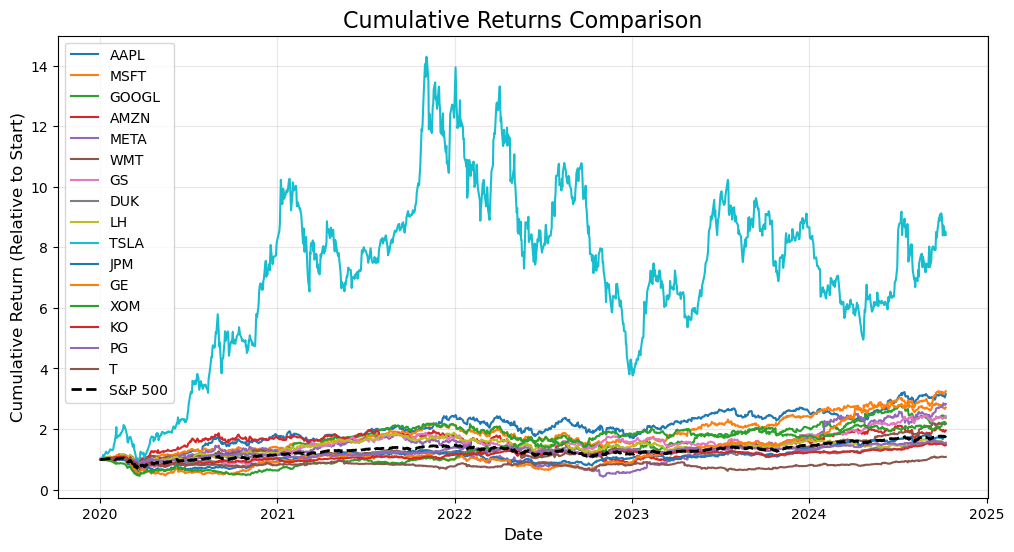

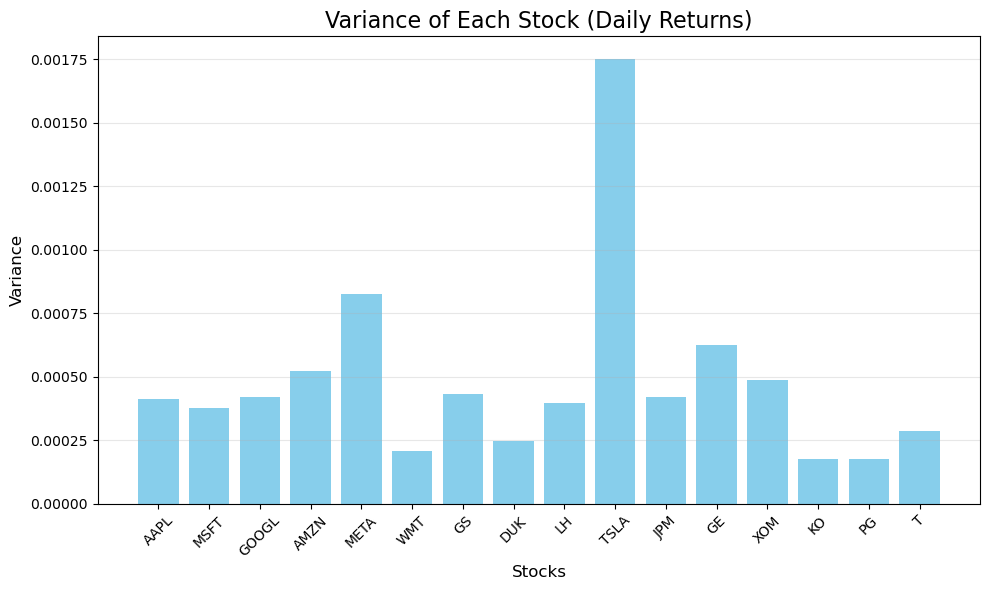

In [73]:

def plot_cumulative_returns(stock_close, index_close, symbols):
    """
    Plots the cumulative returns of each stock vs. the index,
    starting at 1.0 on the first available date.
    """
    data = stock_close.join(index_close, how="inner")  
    cum_returns = data.div(data.iloc[0])  # price / first_price

    plt.figure(figsize=(12, 6))
    for sym in symbols:
        if sym in cum_returns.columns:
            plt.plot(cum_returns[sym], label=sym)
    # Index is now a column named "S&P 500"
    if index_close.name in cum_returns.columns:
        plt.plot(cum_returns[index_close.name], 
                 label=index_close.name, linestyle="--", 
                 linewidth=2, color="black")

    plt.title("Cumulative Returns Comparison", fontsize=16)
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Cumulative Return (Relative to Start)", fontsize=12)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

def plot_stock_variance(stock_close, symbols):
    """
    Plots the variance (based on daily returns) for each stock.
    """
    daily_returns = stock_close.pct_change().dropna()
    variances = daily_returns.var().reindex(symbols)

    plt.figure(figsize=(10, 6))
    plt.bar(variances.index, variances.values, color="skyblue")
    plt.title("Variance of Each Stock (Daily Returns)", fontsize=16)
    plt.xlabel("Stocks", fontsize=12)
    plt.ylabel("Variance", fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

# ------------- GENERATE THE PLOTS --------------------------------
plot_cumulative_returns(stock_close_prices, index_close_prices, symbols)
plot_stock_variance(stock_close_prices, symbols)


## Model and solution

In [74]:
# --- Step 2: Define Model Parameters ---
N = len(symbols)  # Number of stocks
T = len(stock_returns)  # Number of time periods

# Transaction cost coefficients (example values, adjust as needed)
transaction_costs = [0.02879217, 0.01962703, 0.04772307, 0.02391093, 0.02092808, 0.01490304,
 0.04496802, 0.03728759, 0.02653509, 0.0223213, 0.03570548, 0.03718864,
 0.02686864, 0.02676026, 0.02855374, 0.04018206] # np.random.uniform(0.01, 0.05, N) 

# Constraints
budget = 1.0  # Total investment budget (100%)
w_max = 0.2  # Max allocation per stock

# Previous portfolio weights (starting at 0 for every stock)
w_prev = np.zeros(N)



Now, we define the objetcive function:
$$
\text{Minimize: } \mathcal{L}(w) = \sum_{t=1}^T \left( R_t^{\text{portfolio}} - R_t^{\text{index}} \right)^2 + \lambda \cdot \sum_{i=1}^N c_i \sqrt{|w_i - w_i^{\text{prev}}|}
$$

In [75]:
# --- Step 3: Define Objective Function ---
def objective(weights):
    # We convert to numpy arrays
    portfolio_arr = stock_returns.dot(weights).reindex(index_returns.index).to_numpy()
    index_arr = index_returns.to_numpy()
    
    # We compute tracking error as a scalar
    tracking_error = ((portfolio_arr - index_arr)**2).sum()

    # We compute transaction costs as a scalar
    trans_cost = (transaction_costs * np.sqrt(np.abs(weights - w_prev))).sum()

    # We convert to Python float
    return float(tracking_error + trans_cost)



Linear constraints:

In [76]:

# --- Step 4: Define Constraints ---
# Budget Constraint: Ensures the total portfolio allocation sums to 100%
def budget_constraint(weights):
    return budget - np.sum(weights)

# Non-Negativity: Prevents short selling
def non_negativity_constraint(weights):
    return weights  # Ensures all weights >= 0

constraints = [
    {'type': 'eq', 'fun': budget_constraint},
    {'type': 'ineq', 'fun': non_negativity_constraint},
]

# Bounds for each weight (0 <= w_i <= w_max)
bounds = [(0, w_max) for _ in range(N)]


Non-linear constraints:

In [77]:
# --- Step 4.1_ Non-linear Constraints---
# Portfolio variance should not exceed a risk threshold
risk_threshold = 0.03  # Threshold for variance 

# risk (variance) constraint: Controls the portfolio's variance, ensuring it doesn’t exceed a defined threshold.
def risk_constraint(weights):
    portfolio_variance = np.dot(weights.T, np.dot(stock_returns.cov().to_numpy(), weights))
    return risk_threshold - portfolio_variance  # Ensure variance <= threshold

constraints.append({'type': 'ineq', 'fun': risk_constraint})

# Diversification Constraint: Enforces minimum diversification using Shannon entropy.
entropy_threshold = 1.0  # Minimum entropy threshold (adjust as needed)

def diversification_constraint(weights):
    # We avoid log(0) by replacing 0 weights with a small positive value
    epsilon = 1e-6
    normalized_weights = np.clip(weights, epsilon, None)
    entropy = -np.sum(normalized_weights * np.log(normalized_weights))
    return entropy - entropy_threshold  # Ensure entropy >= threshold

constraints.append({'type': 'ineq', 'fun': diversification_constraint})


Solution:

In [78]:
# --- Step 5: Solution of the Optimization Problem ---
# we assume initial equal allocation
w0 = np.array([budget / N] * N)

result = minimize(
    fun=objective,
    x0=w0,
    bounds=bounds,
    constraints=constraints,
    method='SLSQP' 
)

# --- Step 6: Display Results ---
if result.success:
    optimal_weights = result.x
    print("Optimal Weights:", optimal_weights)
    print("Tracking Error + Transaction Cost:", result.fun)
else:
    print("Optimization failed:", result.message)

Optimal Weights: [1.91808854e-01 6.50218284e-02 0.00000000e+00 8.94766028e-02
 1.56366357e-01 1.99630201e-01 0.00000000e+00 1.59554360e-06
 1.05022732e-01 0.00000000e+00 3.41836062e-02 0.00000000e+00
 2.05143915e-03 0.00000000e+00 1.56437563e-01 0.00000000e+00]
Tracking Error + Transaction Cost: 0.09021672378940232


Visualization of the results

In [79]:
# --- Step 7: Visualization of the results ---
if result.success:
    # Create a DataFrame for the optimal weights
    results_df = pd.DataFrame({
        "Stock": symbols,
        "Optimal Weight": optimal_weights
    })
    results_df["Optimal Weight"] = results_df["Optimal Weight"].round(4)  # Round weights for better readability

    # Add total transaction costs and tracking error
    total_transaction_cost = (transaction_costs * np.sqrt(np.abs(optimal_weights - w_prev))).sum()
    tracking_error = ((stock_returns.dot(optimal_weights).reindex(index_returns.index).to_numpy() - index_returns.to_numpy())**2).sum()

    print("\n--- Optimization Results ---")
    print(results_df)

    # Print other relevant metrics
    print(f"\nTracking Error: {tracking_error:.4f}")
    print(f"Total Transaction Cost: {total_transaction_cost:.4f}")
    print(f"Objective Value (Tracking Error + Transaction Cost): {result.fun:.4f}")
else:
    print("Optimization failed:", result.message)



--- Optimization Results ---
    Stock  Optimal Weight
0    AAPL          0.1918
1    MSFT          0.0650
2   GOOGL          0.0000
3    AMZN          0.0895
4    META          0.1564
5     WMT          0.1996
6      GS          0.0000
7     DUK          0.0000
8      LH          0.1050
9    TSLA          0.0000
10    JPM          0.0342
11     GE          0.0000
12    XOM          0.0021
13     KO          0.0000
14     PG          0.1564
15      T          0.0000

Tracking Error: 0.0228
Total Transaction Cost: 0.0675
Objective Value (Tracking Error + Transaction Cost): 0.0902


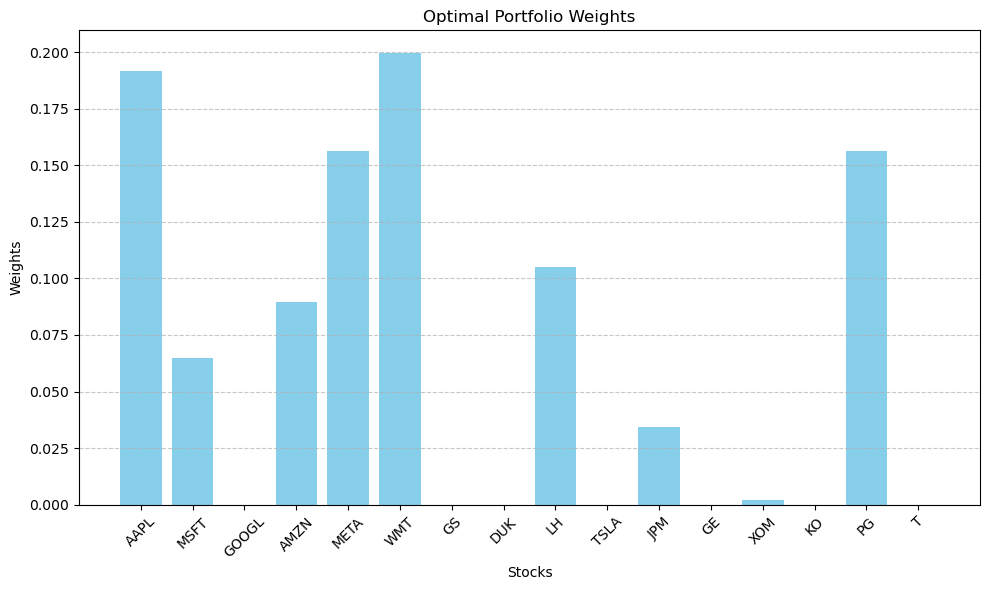

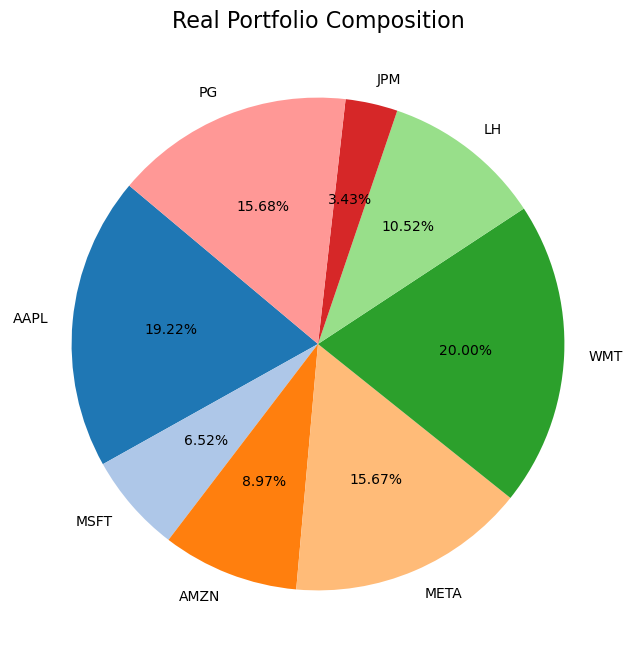

In [80]:
# Plot the optimal weights (Bar Chart)
plt.figure(figsize=(10, 6))
plt.bar(results_df["Stock"], results_df["Optimal Weight"], color="skyblue")
plt.title("Optimal Portfolio Weights")
plt.xlabel("Stocks")
plt.ylabel("Weights")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# Modified Function to Plot Portfolio Composition (Pie Chart)
def plot_real_portfolio_composition(symbols, optimal_weights):
    # Filter stocks with non-zero weights
    non_zero_indices = optimal_weights > 0.01 # for clarity, we remove those stocks with no weight
    filtered_symbols = [symbols[i] for i in range(len(symbols)) if non_zero_indices[i]]
    filtered_weights = optimal_weights[non_zero_indices]

    # Plot pie chart with filtered data
    plt.figure(figsize=(8, 8))
    plt.pie(
        filtered_weights,
        labels=filtered_symbols,
        autopct=lambda p: f'{p:.2f}%',  # Format percentages to two decimal places
        startangle=140,
        colors=plt.cm.tab20.colors[:len(filtered_symbols)]
    )
    plt.title("Real Portfolio Composition", fontsize=16)
    plt.show()

# Check if optimization succeeded and plot the real portfolio composition
if result.success:
    plot_real_portfolio_composition(symbols, optimal_weights)
else:
    print("Optimization failed, no portfolio composition to display.")


Stocks such as META, JPM, DUK, and WMT dominate the portfolio with weights close to or at the maximum allowable limit (20%), suggesting these stocks closely track the S&P 500 index.

Specifically, JPM (19.98%), DUK (20.00%), META (18.93%), and WMT (18.38%) form the core of the portfolio.
Smaller weights like AAPL (2.00%) and T (6.58%) complement the allocation, ensuring diversification while focusing on key contributors.